## Instructions

Student 1: Linear Regression
Notebook must include:
1. Dataset loading and cleaning.
2. EDA relevant to linear regression assumptions.
3. Linear regression model code.
4. Model performance evidence.
5. Coefficient interpretation in markdown.
6. At least one limitation of using linear regression for churn.

## Code

In [36]:
import numpy as np
import pandas as pd

# from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.stattools import durbin_watson

## 1. Dataset Loading and Cleaning

In [6]:
# Load the Customer Churn dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
# cleaning
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# check Size, types, structure
print(df.shape)  # (7043, 21)
df.info()  # dtypes + non-null counts in one view
print(df.dtypes.value_counts())
df.head()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# check nulls and blanks
print(df.isna().sum().sort_values(ascending=False))

blanks = df.astype(str).apply(lambda s: s.str.strip() == "").sum()
print(blanks[blanks > 0])  # TotalCharges: 11

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64
TotalCharges    11
dtype: int64


                 count       mean        std    min   25%    50%    75%  \
SeniorCitizen   7043.0   0.162147   0.368612   0.00   0.0   0.00   0.00   
tenure          7043.0  32.371149  24.559481   0.00   9.0  29.00  55.00   
MonthlyCharges  7043.0  64.761692  30.090047  18.25  35.5  70.35  89.85   

                   max  
SeniorCitizen     1.00  
tenure           72.00  
MonthlyCharges  118.75  
SeniorCitizen     1.833633
tenure            0.239540
MonthlyCharges   -0.220524
dtype: float64


array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>]], dtype=object)

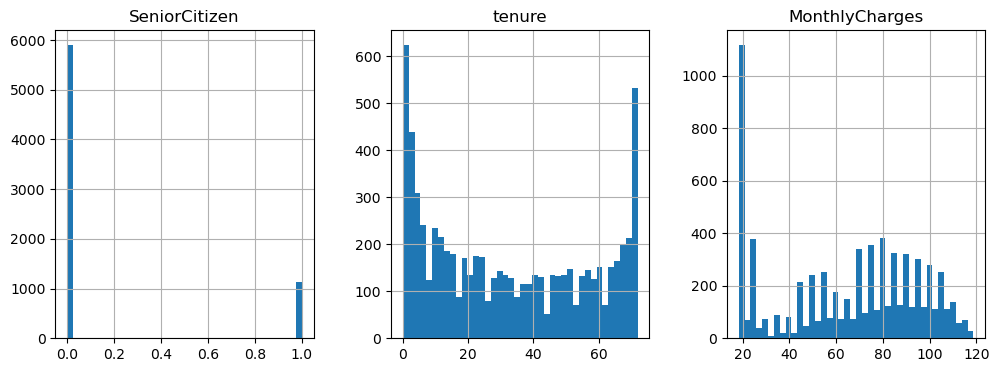

In [12]:
# see numeric feature distributions

num_cols = df.select_dtypes(include=np.number).columns
print(df[num_cols].describe().T)
print(df[num_cols].skew())

df[num_cols].hist(bins=40, figsize=(12, 4), layout=(1, 3))

In [14]:
# check categorical distributions
cat_cols = df.select_dtypes(include="object").columns

summary = pd.DataFrame(
    {
        "n_unique": df[cat_cols].nunique(),
        "values": df[cat_cols].apply(lambda s: s.unique()),
    }
)
print(summary)

for c in cat_cols:
    if df[c].nunique() <= 10:
        print(df[c].value_counts(dropna=False), "\n")

                  n_unique                                             values
customerID            7043  [7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC...
gender                   2                                     [Female, Male]
Partner                  2                                          [Yes, No]
Dependents               2                                          [No, Yes]
PhoneService             2                                          [No, Yes]
MultipleLines            3                        [No phone service, No, Yes]
InternetService          3                             [DSL, Fiber optic, No]
OnlineSecurity           3                     [No, Yes, No internet service]
OnlineBackup             3                     [Yes, No, No internet service]
DeviceProtection         3                     [No, Yes, No internet service]
TechSupport              3                     [No, Yes, No internet service]
StreamingTV              3                     [No, Yes, No inte

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(), errors="coerce"
)

missing_tc = df["TotalCharges"].isna()
print(missing_tc.sum())  # 11
print(df.loc[missing_tc, "tenure"].value_counts())  # all tenure == 0

11
tenure
0    11
Name: count, dtype: int64


In [16]:
# drop 11 rows that are missing TotalCharges
df = df.loc[~missing_tc].reset_index(drop=True)

In [ ]:
# drop CustomerID from features
df = df.drop(columns=["customerID"])

In [ ]:
# collapse "no service" levels
service_cols = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

df[service_cols] = df[service_cols].replace(
    {"No internet service": "No", "No phone service": "No"}
)

print({c: sorted(df[c].unique()) for c in service_cols})  # all now ['No', 'Yes']

{'MultipleLines': ['No', 'Yes'], 'OnlineSecurity': ['No', 'Yes'], 'OnlineBackup': ['No', 'Yes'], 'DeviceProtection': ['No', 'Yes'], 'TechSupport': ['No', 'Yes'], 'StreamingTV': ['No', 'Yes'], 'StreamingMovies': ['No', 'Yes']}


In [ ]:
# normalize binary columns
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn",
] + service_cols

df[binary_cols] = df[binary_cols].apply(
    lambda s: s.str.strip().map({"Yes": 1, "No": 0})
)
print(df[binary_cols].isna().sum().sum())  # 0 — nothing failed to map

# gender is binary but not Yes/No; rename so the encoding is self-documenting
df["gender"] = (df["gender"].str.strip() == "Female").astype(int)
df = df.rename(columns={"gender": "is_female"})

df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)  # already 0/1

0


In [ ]:
# Encode the multi-level categoricals
multi_cols = ["InternetService", "Contract", "PaymentMethod"]

df_enc = pd.get_dummies(df, columns=multi_cols, drop_first=True, dtype=int)

print(df_enc.shape)  # (7032, 24)
print([c for c in df_enc.columns if "_" in c])

(7032, 24)
['is_female', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [ ]:
# sanity checks after cleaning

print(df_enc.dtypes.value_counts())  # int64: 22, float64: 2

leftover = df_enc.select_dtypes(include=["object", "string"]).columns.tolist()
print("object columns remaining:", leftover)  # [] — nothing was missed

int64      22
float64     2
Name: count, dtype: int64
object columns remaining: []


## 2. EDA relevant to linear regression assumptions.

In [ ]:
# train test split
TARGET = "Churn"

y = df_enc[TARGET]
X = df_enc.drop(columns=[TARGET])
X_c = sm.add_constant(X.astype(float))

base = sm.OLS(y, X_c).fit()
print(f"R2 = {base.rsquared:.4f}   n = {int(base.nobs)}")  # R2 = 0.2841, n = 7032

R2 = 0.2841   n = 7032


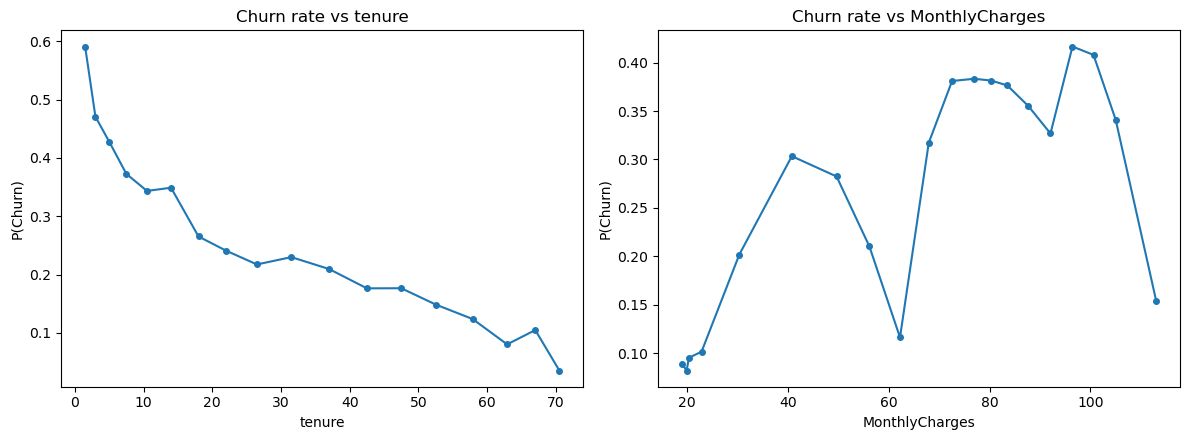

In [29]:
cont = ["tenure", "MonthlyCharges"]
fig, axes = plt.subplots(1, len(cont), figsize=(12, 4.5))

for ax, col in zip(axes, cont):
    bins = pd.qcut(df_enc[col], 20, duplicates="drop")
    means = y.groupby(bins, observed=True).mean()
    mids = means.index.map(lambda iv: iv.mid).astype(float)
    ax.plot(mids, means.values, marker="o", ms=4)
    ax.set(xlabel=col, ylabel="P(Churn)", title=f"Churn rate vs {col}")

plt.tight_layout()
plt.show()

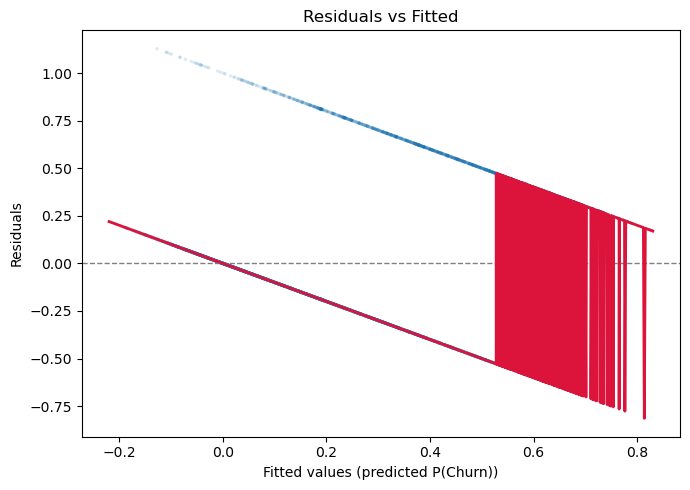

In [ ]:
# residual plots
fitted, resid = base.fittedvalues, base.resid

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fitted, resid, s=6, alpha=0.15, edgecolors="none")
ax.axhline(0, color="gray", lw=1, ls="--")
sm_fit = lowess(resid, fitted, frac=0.3, return_sorted=True)
ax.plot(sm_fit[:, 0], sm_fit[:, 1], color="crimson", lw=2)
ax.set(
    xlabel="Fitted values (predicted P(Churn))",
    ylabel="Residuals",
    title="Residuals vs Fitted",
)
plt.tight_layout()
plt.show()

#### linearity seems to be violated!
This is mainly because the Target column is binary but we're fitting linear regression to it, which assumes a continuous target variable.

In [ ]:
# RESET test
for p in (2, 3, 4):
    r = linear_reset(base, power=p, test_type="fitted", use_f=True)
    print(f"RESET (powers up to {p}):  F = {r.statistic:>8.2f}   p = {r.pvalue:.3e}")

RESET (powers up to 2):  F =   206.06   p = 4.467e-46
RESET (powers up to 3):  F =   106.73   p = 2.188e-46
RESET (powers up to 4):  F =    72.28   p = 4.946e-46


#### Very large F, so linearity is violated again.

In [ ]:
dw = durbin_watson(resid)
print(f"Durbin-Watson statistic: {dw:.4f}")

Durbin-Watson statistic: 2.0043


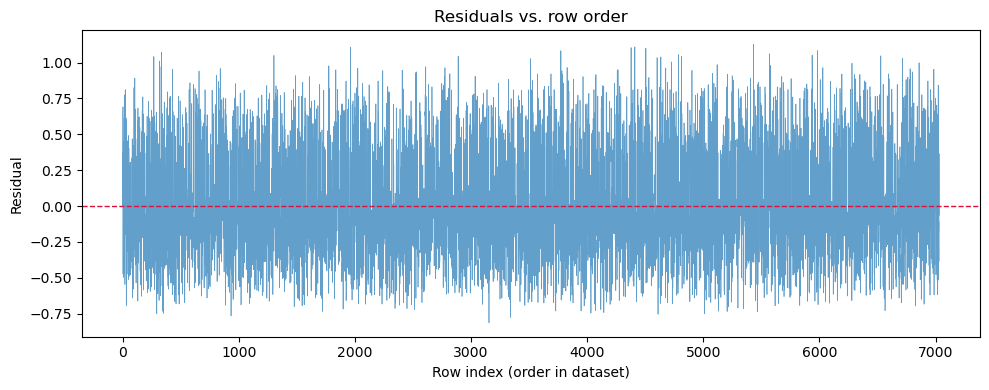

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(resid.values, lw=0.5, alpha=0.7)
ax.axhline(0, color="crimson", lw=1, ls="--")
ax.set(
    xlabel="Row index (order in dataset)",
    ylabel="Residual",
    title="Residuals vs. row order",
)
plt.tight_layout()
plt.show()

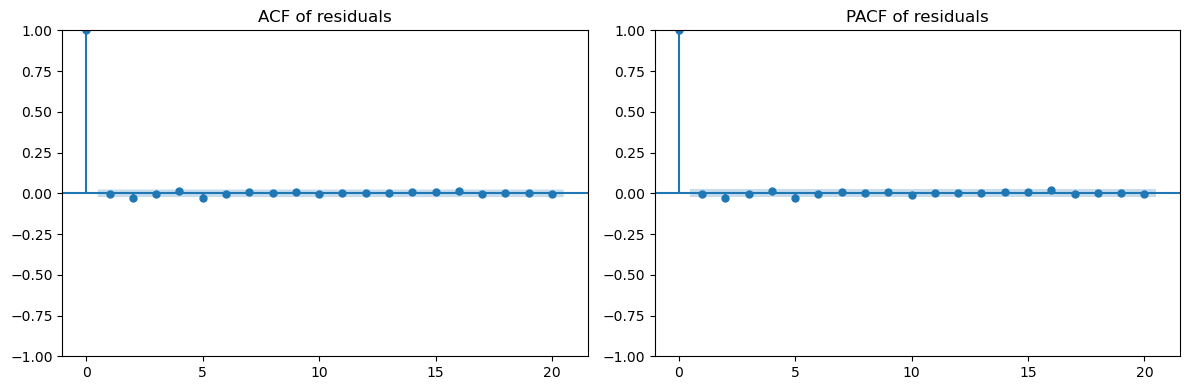

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, lags=20, ax=axes[0], title="ACF of residuals")
plot_pacf(resid, lags=20, ax=axes[1], method="ywm", title="PACF of residuals")
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import acf, pacf

print("ACF, lags 1-5:", np.round(acf(resid, nlags=5, fft=True)[1:], 4))
print("PACF, lags 1-5:", np.round(pacf(resid, nlags=5, method="ywm")[1:], 4))

ACF, lags 1-5: [-0.0023 -0.0296 -0.0043  0.0132 -0.0269]
PACF, lags 1-5: [-0.0023 -0.0296 -0.0045  0.0123 -0.0271]


#### NO autocorrelation found among variables.
This is a good sign for model fit.

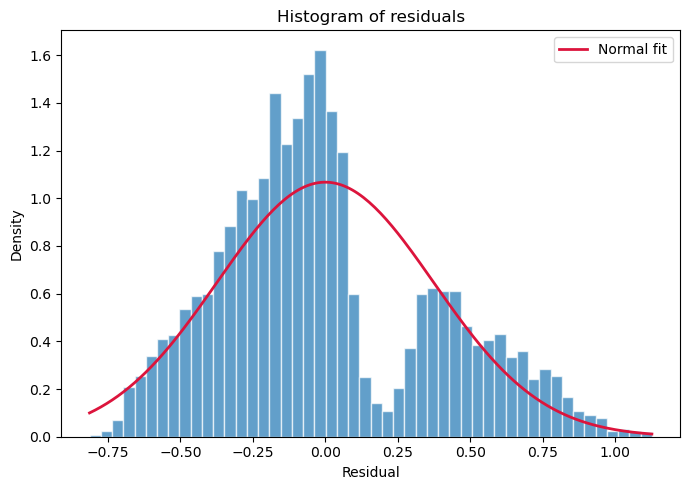

In [ ]:
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(resid, bins=50, density=True, alpha=0.7, edgecolor="white")

mu, sigma = resid.mean(), resid.std()
xs = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, mu, sigma), color="crimson", lw=2, label="Normal fit")

ax.set(xlabel="Residual", ylabel="Density", title="Histogram of residuals")
ax.legend()
plt.tight_layout()
plt.show()

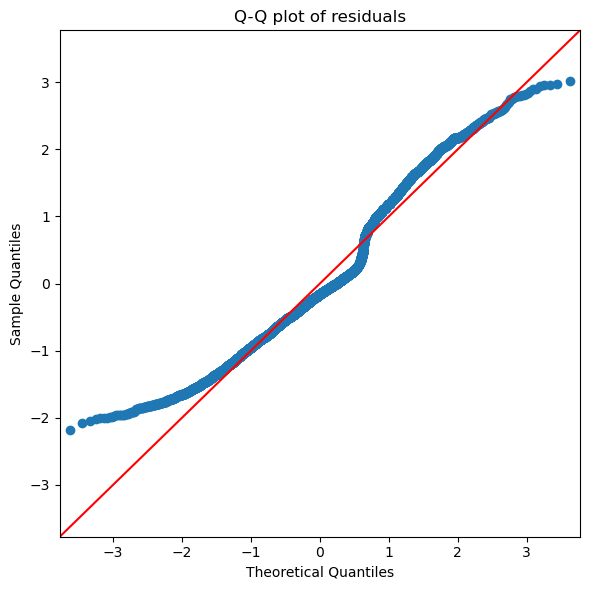

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(resid, line="45", fit=True, ax=ax)
ax.set_title("Q-Q plot of residuals")
plt.tight_layout()
plt.show()

In [ ]:
n = len(resid)
if n > 5000:
    sample = resid.sample(
        5000, random_state=0
    )  # scipy's Shapiro is only validated up to n≈5000
else:
    sample = resid
sw_stat, sw_p = stats.shapiro(sample)
print(f"Shapiro-Wilk: stat={sw_stat:.4f}, p={sw_p:.3e}  (n_used={len(sample)})")

Shapiro-Wilk: stat=0.9641, p=1.533e-33  (n_used=5000)


In [ ]:
ad = stats.anderson(resid, dist="norm")
print(f"Anderson-Darling statistic: {ad.statistic:.4f}")
for cv, sig in zip(ad.critical_values, ad.significance_level):
    print(f"  {sig:>5}% significance -> critical value {cv}")

Anderson-Darling statistic: 102.1841
   15.0% significance -> critical value 0.576
   10.0% significance -> critical value 0.656
    5.0% significance -> critical value 0.787
    2.5% significance -> critical value 0.917
    1.0% significance -> critical value 1.091


In [ ]:
jb_stat, jb_p, skew, kurt = sm.stats.stattools.jarque_bera(resid)
print(
    f"Jarque-Bera: stat={jb_stat:.2f}, p={jb_p:.3e}, skew={skew:.4f}, kurtosis={kurt:.4f}"
)

Jarque-Bera: stat=385.49, p=1.959e-84, skew=0.5501, kurtosis=2.6757


#### Normality is violated too.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_enc.drop(columns=["Churn"]).astype(float)
X_c = sm.add_constant(X)

In [ ]:
vif = pd.DataFrame(
    {
        "feature": X_c.columns,
        "VIF": [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])],
    }
).sort_values("VIF", ascending=False)

print(vif.to_string(index=False))

                              feature        VIF
                       MonthlyCharges 866.089640
          InternetService_Fiber optic 148.500814
                   InternetService_No 104.213701
                         PhoneService  34.893857
                      StreamingMovies  24.156394
                          StreamingTV  24.080019
                         TotalCharges  10.811490
                               tenure   7.584453
                        MultipleLines   7.289761
                     DeviceProtection   6.924754
                         OnlineBackup   6.796678
                          TechSupport   6.476508
                       OnlineSecurity   6.338349
                    Contract_Two year   2.652328
       PaymentMethod_Electronic check   1.976032
           PaymentMethod_Mailed check   1.857058
                    Contract_One year   1.625784
PaymentMethod_Credit card (automatic)   1.560999
                              Partner   1.462988
                    

In [ ]:
corr = X.corr()

# ranked list of the strongest pairwise correlations, not just the full matrix
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
print(pairs.head(15))

tenure            TotalCharges                   0.825880
MonthlyCharges    InternetService_Fiber optic    0.787195
                  InternetService_No            -0.763191
                  TotalCharges                   0.651065
StreamingTV       MonthlyCharges                 0.629668
StreamingMovies   MonthlyCharges                 0.627235
tenure            Contract_Two year              0.563801
StreamingTV       StreamingMovies                0.533380
DeviceProtection  TotalCharges                   0.522881
StreamingMovies   TotalCharges                   0.519867
StreamingTV       TotalCharges                   0.515709
OnlineBackup      TotalCharges                   0.510100
MultipleLines     MonthlyCharges                 0.490912
DeviceProtection  MonthlyCharges                 0.482607
MultipleLines     TotalCharges                   0.469042
dtype: float64


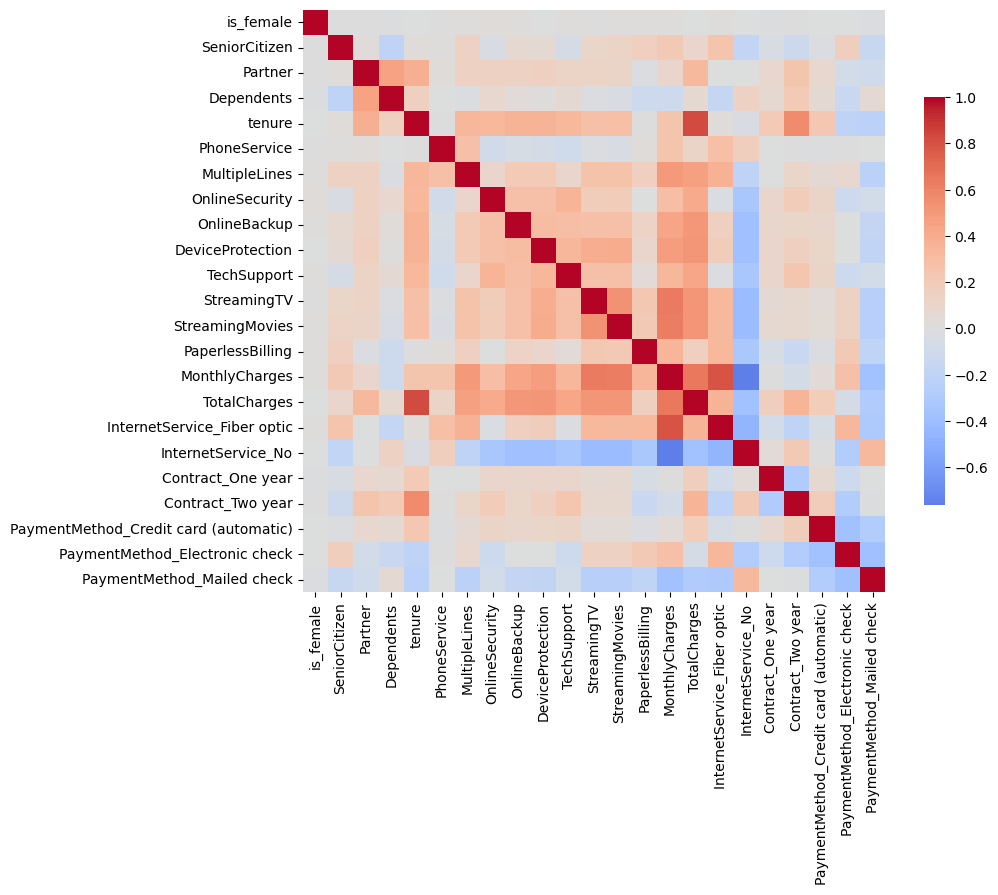

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"shrink": 0.7}
)
plt.tight_layout()
plt.show()

In [ ]:
model = sm.OLS(df_enc["Churn"], X_c).fit()
print(
    "Condition number (statsmodels, on raw design matrix):",
    round(model.condition_number, 2),
)

Condition number (statsmodels, on raw design matrix): 160740.08


In [ ]:
X_std = (X - X.mean()) / X.std()
X_std_c = sm.add_constant(X_std)
print("Condition number on standardized X:", round(np.linalg.cond(X_std_c.values), 2))

Condition number on standardized X: 81.74


In [ ]:
X_std = (X - X.mean()) / X.std()
corr_mat = X_std.corr()

eigvals = np.linalg.eigh(corr_mat.values)[0][::-1]  # descending
cond_indices = np.sqrt(eigvals[0] / eigvals)

eig_table = pd.DataFrame({"eigenvalue": eigvals, "condition_index": cond_indices})
print(eig_table.round(4).to_string())

    eigenvalue  condition_index
0       5.4817           1.0000
1       3.0007           1.3516
2       1.6086           1.8460
3       1.2424           2.1005
4       1.2245           2.1158
5       1.1618           2.1721
6       1.0037           2.3370
7       0.9733           2.3732
8       0.8933           2.4772
9       0.8788           2.4976
10      0.7849           2.6427
11      0.6916           2.8153
12      0.6283           2.9538
13      0.6033           3.0144
14      0.5928           3.0410
15      0.4949           3.3280
16      0.4653           3.4325
17      0.4519           3.4827
18      0.2828           4.4028
19      0.2489           4.6927
20      0.2283           4.9006
21      0.0574           9.7724
22      0.0008          81.7358


#### We also see multicollinearity.
Severe multicollinearity is concentrated in MonthlyCharges, the InternetService dummies, PhoneService, and the streaming add-ons, plus the previously-known tenure/TotalCharges/MonthlyCharges near-identity.

Threshold (4/n): 0.000569
Points exceeding 4/n: 285  (4.05%)
Points exceeding 1 (classic rule of thumb): 0


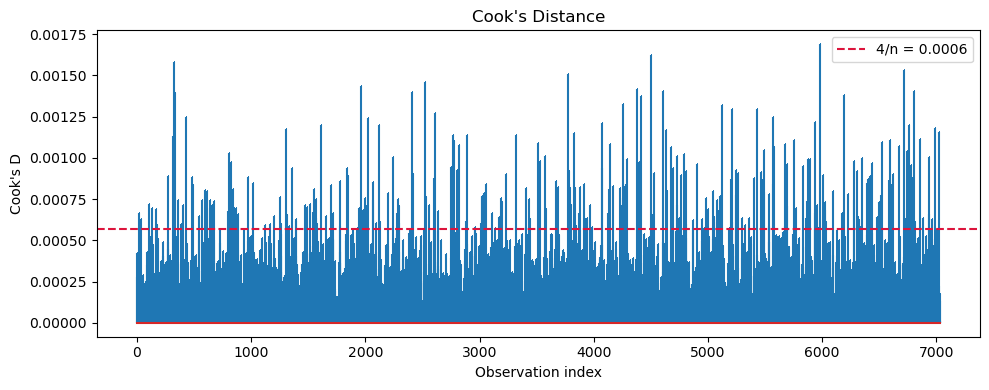

In [ ]:
influence = base.get_influence()  # single object drives all three diagnostics

cooks_d, _ = influence.cooks_distance

thresh = 4 / n
flagged_cook = np.where(cooks_d > thresh)[0]

print(f"Threshold (4/n): {thresh:.6f}")
print(f"Points exceeding 4/n: {len(flagged_cook)}  ({len(flagged_cook)/n*100:.2f}%)")
print(f"Points exceeding 1 (classic rule of thumb): {(cooks_d > 1).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(cooks_d, markerfmt=",")
ax.axhline(thresh, color="crimson", ls="--", label=f"4/n = {thresh:.4f}")
ax.set(xlabel="Observation index", ylabel="Cook's D", title="Cook's Distance")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
top5 = np.argsort(cooks_d)[::-1][:5]
print(df.iloc[top5][["tenure", "MonthlyCharges", "TotalCharges", "Contract"]])
print("actual churn:", y.iloc[top5].values)
print("predicted:", base.fittedvalues.iloc[top5].round(3).values)

      tenure  MonthlyCharges  TotalCharges  Contract
5983      65           72.45       4653.85  One year
4505      72           92.45       6440.25  Two year
320       54           82.45       4350.10  One year
6714      64           70.20       4481.00  Two year
3773      66           79.40       5154.60  Two year
actual churn: [1 1 1 1 1]
predicted: [-0.083 -0.099  0.029 -0.03  -0.082]


|studentized resid| > 3: 1
|studentized resid| > 2: 292  (4.15%)
range: -2.177 to 3.018


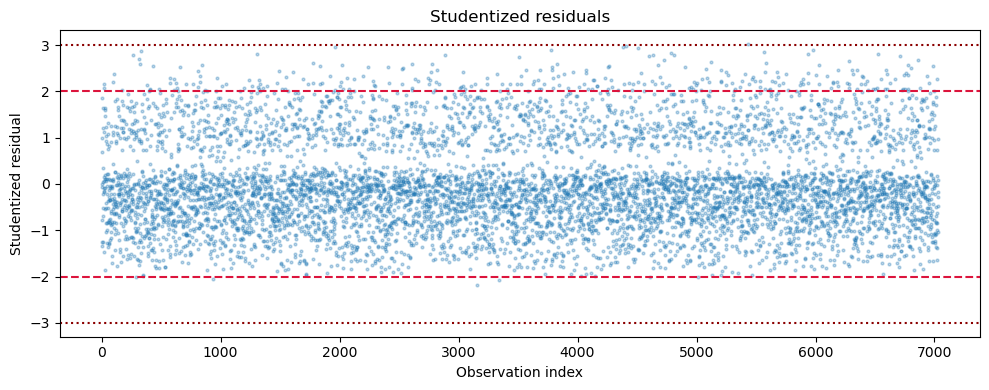

In [57]:
stud_resid = influence.resid_studentized_external

print(f"|studentized resid| > 3: {(np.abs(stud_resid) > 3).sum()}")
print(
    f"|studentized resid| > 2: {(np.abs(stud_resid) > 2).sum()}  ({(np.abs(stud_resid) > 2).mean()*100:.2f}%)"
)
print(f"range: {stud_resid.min():.3f} to {stud_resid.max():.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(stud_resid)), stud_resid, s=4, alpha=0.3)
ax.axhline(2, color="crimson", ls="--")
ax.axhline(-2, color="crimson", ls="--")
ax.axhline(3, color="darkred", ls=":")
ax.axhline(-3, color="darkred", ls=":")
ax.set(
    xlabel="Observation index",
    ylabel="Studentized residual",
    title="Studentized residuals",
)
plt.tight_layout()
plt.show()

In [ ]:
dfbetas = influence.dfbetas  # shape: (n_obs, n_params)
thresh_dfb = 2 / np.sqrt(n)

exceed = np.abs(dfbetas) > thresh_dfb
per_coef = pd.Series(exceed.sum(axis=0), index=X_c.columns).sort_values(ascending=False)

print(f"Threshold (2/sqrt(n)): {thresh_dfb:.4f}")
print(per_coef.head(10))
print(
    f"\nRows exceeding threshold on at least one coefficient: "
    f"{exceed.any(axis=1).sum()} ({exceed.any(axis=1).mean()*100:.2f}%)"
)

#### No major problem about outliers detected.

## 3. Linear regression model code and 4. Model performance evidence.

In [ ]:
# Split features and target
X = df_enc.drop(columns=["Churn"])
y = df_enc["Churn"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}:")
    print(f"MSE: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")

    for feature, coef in zip(X.columns, model.coef_):
        print(f"{feature}: {coef:.4f}")

    return model, y_pred

In [ ]:
# Fit models
lr_model, lr_pred = evaluate_model(
    LinearRegression(),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Linear Regression",
)
ridge_model, ridge_pred = evaluate_model(
    Ridge(alpha=1.0), X_train_scaled, X_test_scaled, y_train, y_test, "Ridge Regression"
)
lasso_model, lasso_pred = evaluate_model(
    Lasso(alpha=0.1), X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression"
)


Linear Regression:
MSE: 0.1459
R2 Score: 0.2522
is_female: 0.0018
SeniorCitizen: 0.0201
Partner: 0.0035
Dependents: -0.0130
tenure: -0.0463
PhoneService: 0.0127
MultipleLines: 0.0338
OnlineSecurity: -0.0168
OnlineBackup: 0.0036
DeviceProtection: 0.0102
TechSupport: -0.0172
StreamingTV: 0.0449
StreamingMovies: 0.0465
PaperlessBilling: 0.0177
MonthlyCharges: -0.1109
TotalCharges: -0.1030
InternetService_Fiber optic: 0.1358
InternetService_No: -0.0966
Contract_One year: -0.0477
Contract_Two year: -0.0318
PaymentMethod_Credit card (automatic): -0.0039
PaymentMethod_Electronic check: 0.0295
PaymentMethod_Mailed check: -0.0027

Ridge Regression:
MSE: 0.1459
R2 Score: 0.2523
is_female: 0.0019
SeniorCitizen: 0.0201
Partner: 0.0035
Dependents: -0.0130
tenure: -0.0464
PhoneService: 0.0072
MultipleLines: 0.0315
OnlineSecurity: -0.0189
OnlineBackup: 0.0014
DeviceProtection: 0.0080
TechSupport: -0.0193
StreamingTV: 0.0404
StreamingMovies: 0.0420
PaperlessBilling: 0.0177
MonthlyCharges: -0.0831
Tot

<Figure size 1200x600 with 0 Axes>

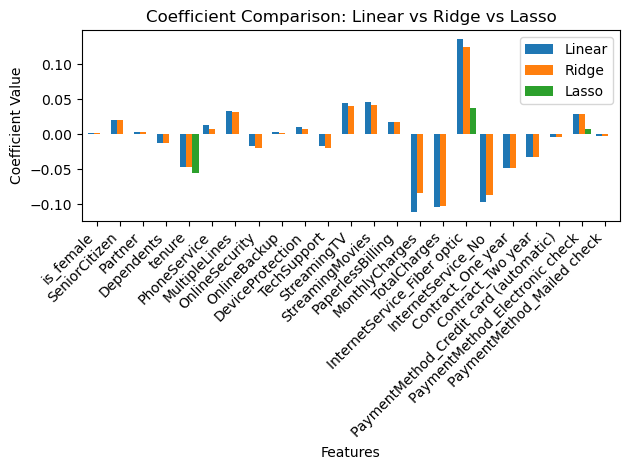

In [ ]:
# Coefficient Comparison Plot
def plot_coefficients(lr_model, ridge_model, lasso_model):
    coef_df = pd.DataFrame(
        {
            "Linear": lr_model.coef_,
            "Ridge": ridge_model.coef_,
            "Lasso": lasso_model.coef_,
        },
        index=X.columns,
    )

    plt.figure(figsize=(12, 6))
    coef_df.plot(kind="bar", width=0.8)
    plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")
    plt.xlabel("Features")
    plt.ylabel("Coefficient Value")
    plt.legend(loc="best")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


plot_coefficients(lr_model, ridge_model, lasso_model)

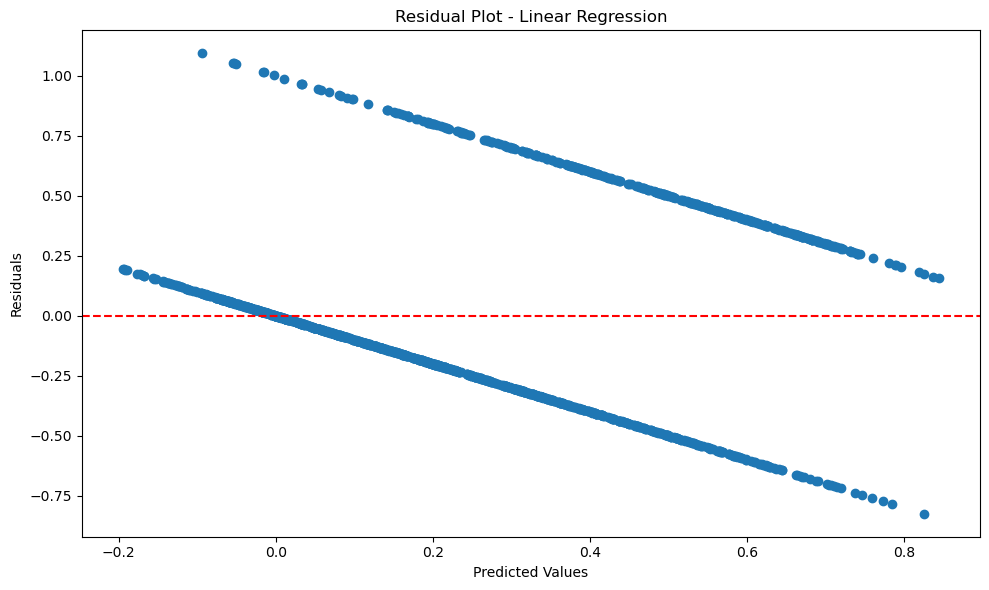

In [ ]:
# Residual Plot
def plot_residuals(y_test, y_pred, model_name):
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot - {model_name}")
    plt.axhline(y=0, color="r", linestyle="--")
    plt.tight_layout()
    plt.show()


plot_residuals(y_test, lr_pred, "Linear Regression")

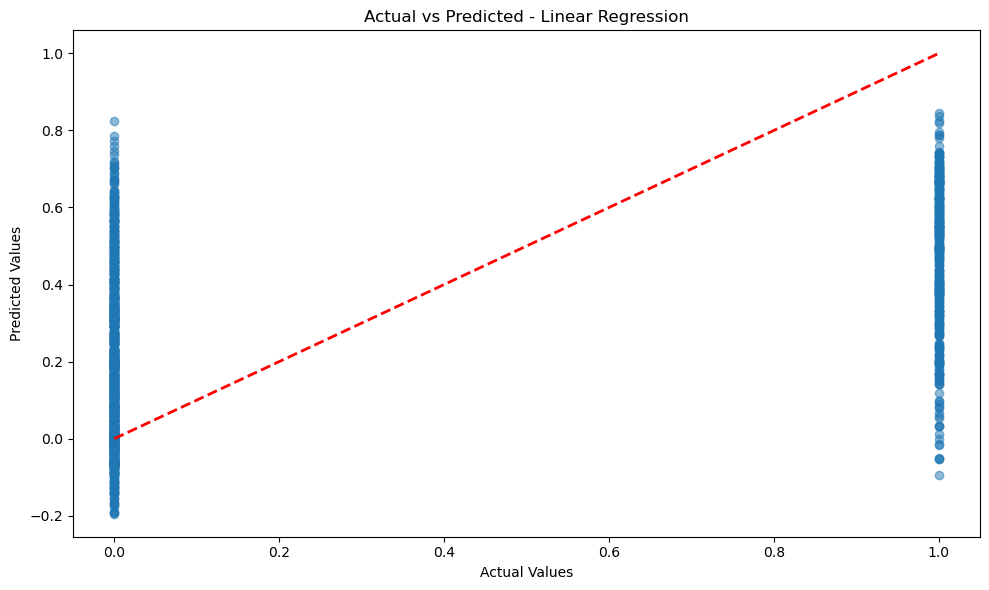

In [ ]:
# Actual vs Predicted Plot
def plot_actual_vs_predicted(y_test, y_pred, model_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(y_test, lr_pred, "Linear Regression")

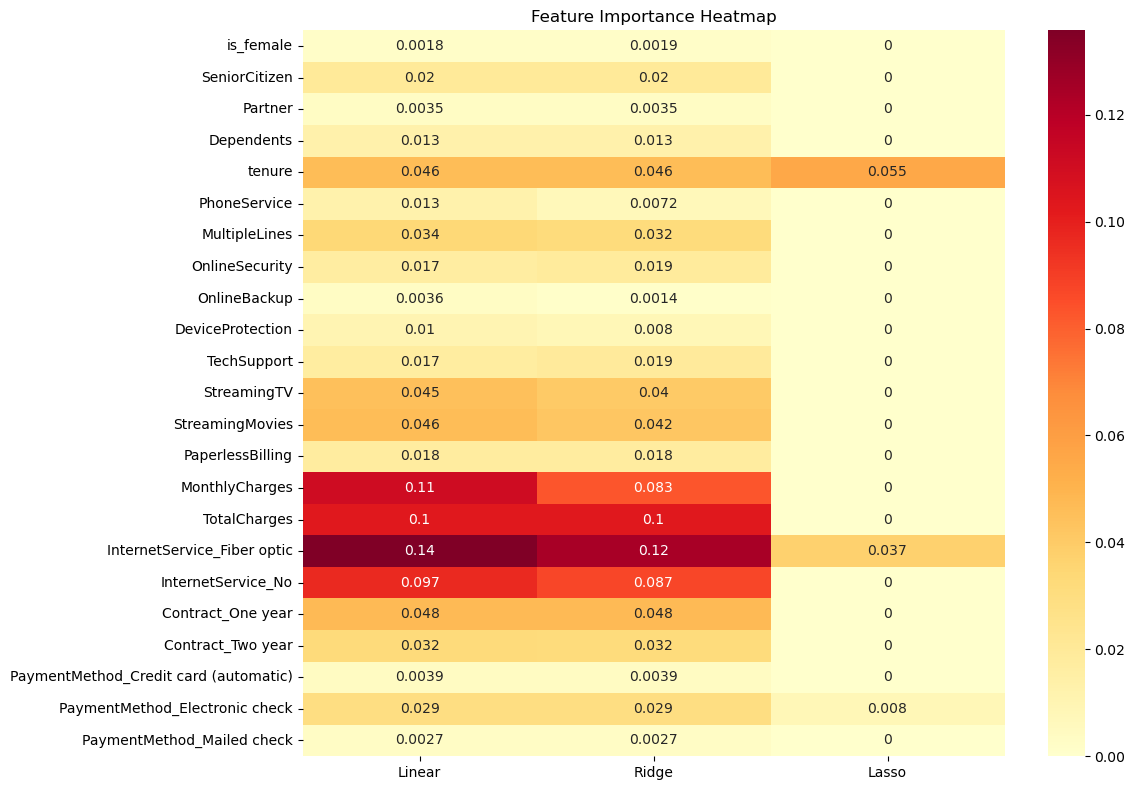

In [ ]:
# Feature Importance Heatmap
def plot_feature_importance_heatmap(lr_model, ridge_model, lasso_model):
    importance_df = pd.DataFrame(
        {
            "Linear": np.abs(lr_model.coef_),
            "Ridge": np.abs(ridge_model.coef_),
            "Lasso": np.abs(lasso_model.coef_),
        },
        index=X.columns,
    )

    plt.figure(figsize=(12, 8))
    sns.heatmap(importance_df, annot=True, cmap="YlOrRd")
    plt.title("Feature Importance Heatmap")
    plt.tight_layout()
    plt.show()


plot_feature_importance_heatmap(lr_model, ridge_model, lasso_model)

## 5. Coefficient interpretation in markdown and 6. At least one limitation of using linear regression for churn.

The model's R² of 0.2522 means the linear specification explains about 25.2% of the variance in the binary Churn outcome, leaving roughly three-quarters of the variation in churn behavior unaccounted for.

An MSE of 0.1459 corresponds to a root-mean-squared error of about 0.382, meaning the model's predicted "probabilities" typically miss the true 0/1 churn label by roughly 0.38 in probability units.

InternetService_Fiber optic (coef = 0.1358) is the strongest driver in the model, with a one-standard-deviation shift toward having fiber internet associated with a 0.1358-unit increase in predicted churn probability, holding the other standardized predictors constant.

MonthlyCharges (coef = −0.1109) shows a one-standard-deviation increase associated with a 0.1109-unit decrease in predicted churn probability, a counterintuitive sign that's more likely an artifact of its severe collinearity with InternetService_Fiber optic and TotalCharges (VIF ≈ 866) than a genuine protective effect of higher bills.

TotalCharges (coef = −0.1030) is associated with a 0.1030-unit decrease in predicted churn probability per standard-deviation increase, broadly consistent with long-tenured, high-lifetime-value customers churning less, though this estimate is similarly destabilized by its 0.83 correlation with tenure.

InternetService_No (coef = −0.0966) shows customers without internet service carrying a 0.0966-unit lower predicted churn probability per standard-deviation shift, reinforcing that churn risk is concentrated almost entirely in the internet-subscribing segment.

Contract_One year (coef = −0.0477) is associated with a 0.0477-unit lower predicted churn probability relative to the month-to-month reference category, confirming that locking into a longer contract meaningfully reduces churn likelihood.

#### Limitation
The target variable is binary in nature, so linear regression is not a great way to model its fit. Logistic regression could be a better choice.